# Part I - Ford GoBike System Data
## by Raghad

## Introduction

> Introduce the dataset:
The Ford GoBike System Dataset contains detailed information about trips made on the Ford GoBike bike sharing in the San Francisco Bay area.

The dataset provides valuable insight into how people in the Bay Area use shared bikes for certain activiteis 
>**Rubric Tip**: Your code should not generate any errors, and should use functions, loops where possible to reduce repetitive code. Prefer to use functions to reuse code statements.

> **Rubric Tip**: Document your approach and findings in markdown cells. Use comments and docstrings in code cells to document the code functionality.

>**Rubric Tip**: Markup cells should have headers and text that organize your thoughts, findings, and what you plan on investigating next.  

## Preliminary Wrangling

In [2]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.

> Note that the collective size of all your files in the current worksapce **must not exceed 1 GB** in total. 


In [3]:
df= pd.read_csv('201902-fordgobike-tripdata.csv')
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [4]:
df.shape

(183412, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [6]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


we can already see that the dataset have dempgraphic info, station info and other data with time stamps.
it has missing values in some columns.


### What is the structure of your dataset?

> it is a CSV file

### What is/are the main feature(s) of interest in your dataset?

> the main features of interest in this dataset are the trip duration, start time, and user type

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> trip duration, the start and end time.

## Univariate Exploration

> In this section, investigate distributions of individual variables. If you see unusual points or outliers, take a deeper look to clean things up and prepare yourself to look at relationships between variables.

>**Rubric Tip**: Use the "Question-Visualization-Observations" framework  throughout the exploration. This framework involves **asking a question from the data, creating a visualization to find answers, and then recording observations after each visualisation.** 

> **Rubric Tip**: This part (Univariate Exploration) should include at least one histogram, and either a bar chart of count plot.

>**Rubric Tip**: Visualizations should depict the data appropriately so that the plots are easily interpretable. You should choose an appropriate plot type, data encodings, and formatting as needed. The formatting may include setting/adding the title, labels, legend, and comments. Also, do not overplot or incorrectly plot ordinal data.

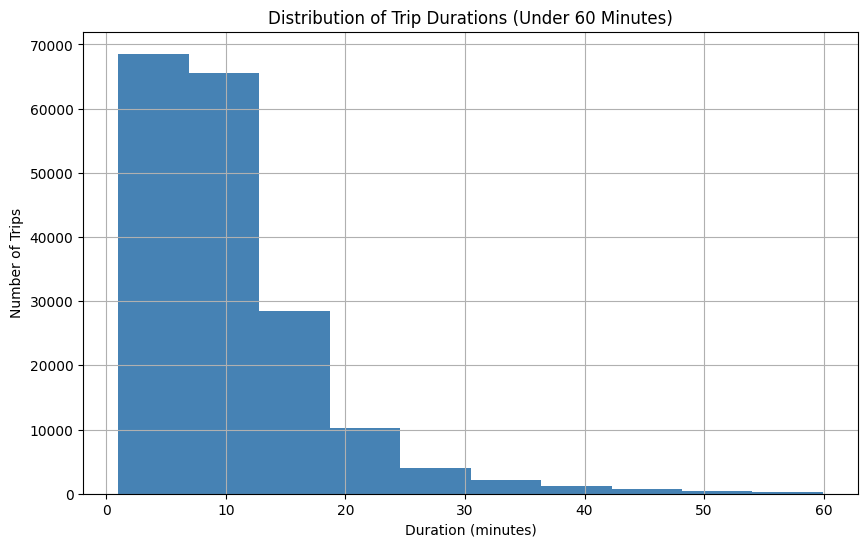

In [7]:
# question 1: what is the distribution of trip durations? 

df['duration_min'] = df['duration_sec'] / 60


plt.figure(figsize=(10,6))
bins = np.arange(0, 61, 1)
plt.hist(df[df['duration_min'] <= 60]['duration_min'], color='steelblue')
plt.title('Distribution of Trip Durations (Under 60 Minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Trips')
plt.grid()
plt.show()

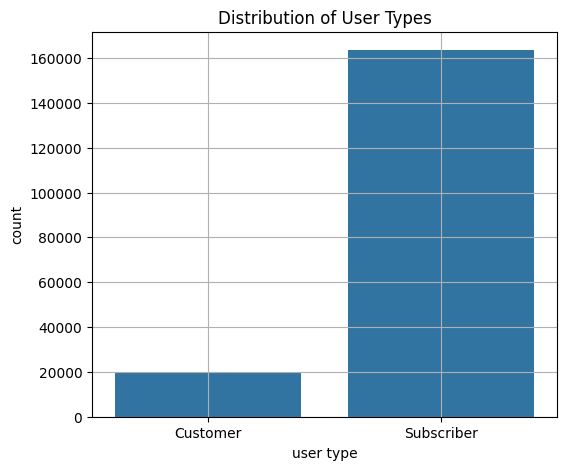

In [8]:
#Question2: What is the distribution of user type? 
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='user_type')
plt.title('Distribution of User Types')
plt.xlabel('user type')
plt.ylabel('count')
plt.grid()
plt.show()

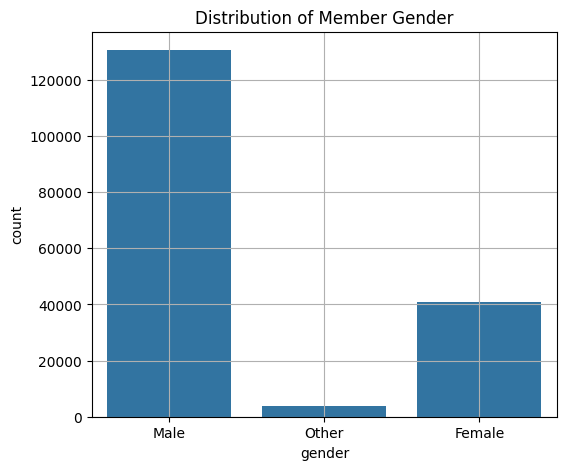

In [9]:
#Question3: what is the gender distribution of users?
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='member_gender')
plt.title('Distribution of Member Gender')
plt.xlabel('gender')
plt.ylabel('count')
plt.grid()
plt.show()

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

>The main variable of interest, trip duration, showed a highly right-skewed distribution. Most trips were under 20 minutes. To make the distribution clearer and avoid distortion from extreme values, I focused the histogram on trips under 60 minutes. This revealed a shape of typical usage patterns without the noise from outliers.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> Yes, there were a few unusual patterns and data adjustments where a small number of trips had very long durations, which are likely due to users forgetting to end the trip also the member_gender column included an "Other" category with a very small number of entries, it was not cleaned or removed.


## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).

> **Rubric Tip**: This part (Bivariate Exploration) should include at least one scatter plot, one box plot, and at least one clustered bar chart or heat map.

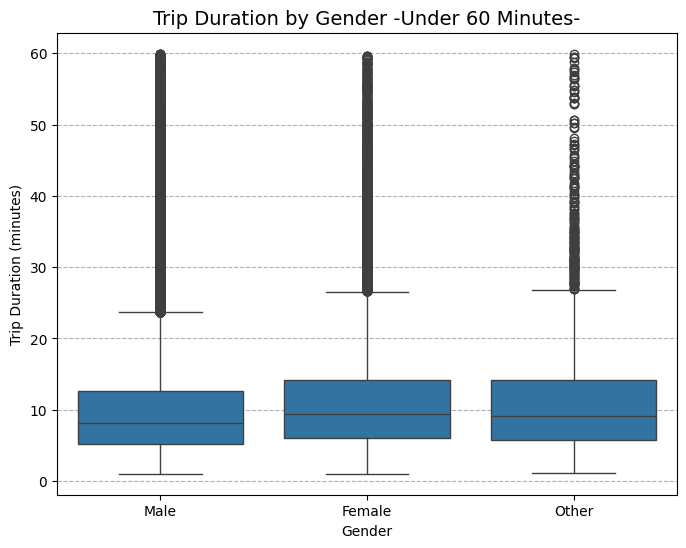

In [11]:
#this inspect: how does trip duration vary across different genders?
filtered_df = df[df['duration_min'] <= 60]

plt.figure(figsize=(8,6))
sns.boxplot(data=filtered_df, x='member_gender', y='duration_min')
plt.title('Trip Duration by Gender -Under 60 Minutes-', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Trip Duration (minutes)')
plt.grid(axis='y', linestyle='--')
plt.show()

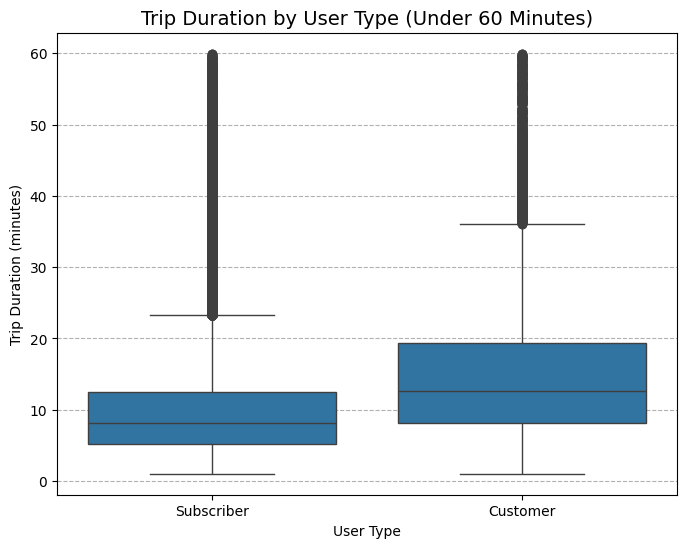

In [12]:
#Is there a relationship between trip duration and user type?

plt.figure(figsize=(8,6))
sns.boxplot(data=filtered_df, x='user_type', y='duration_min')
plt.title('Trip Duration by User Type (Under 60 Minutes)', fontsize=14)
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.grid(axis='y', linestyle='--')
plt.show()

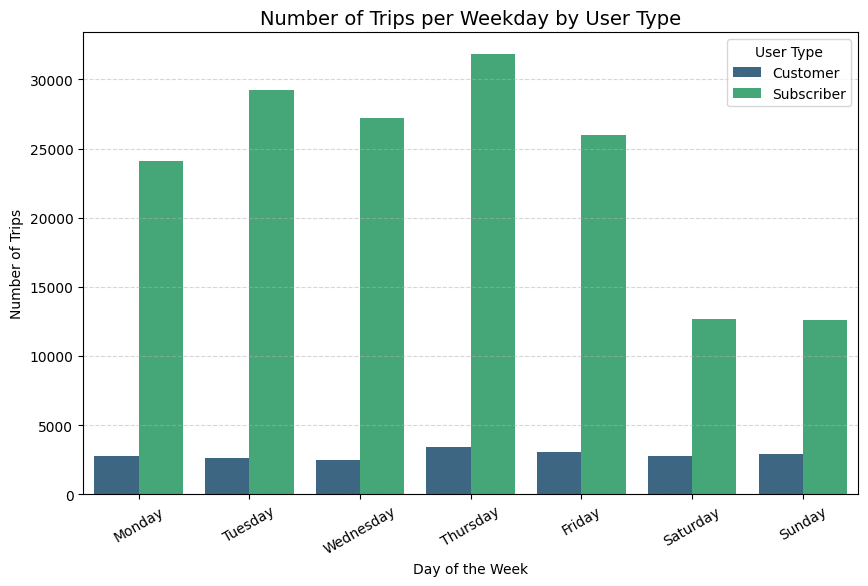

In [13]:
# How are trip counts distributed across weekdays for each user type?
df['start_time'] = pd.to_datetime(df['start_time'])
df['weekday'] = df['start_time'].dt.day_name()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='weekday', hue='user_type', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='viridis')
plt.title('Number of Trips per Weekday by User Type', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='User Type')
plt.show()


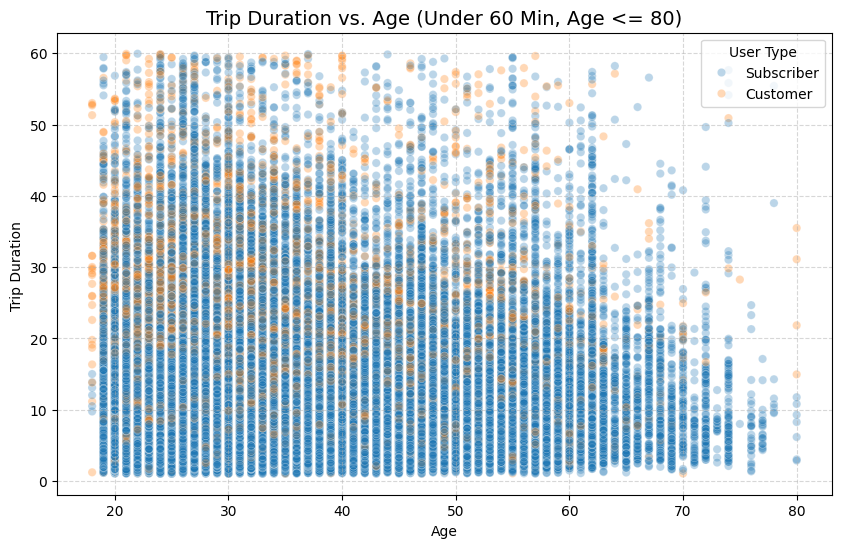

In [15]:
# Is there a correlation between user age and trip duration?

df['age'] = 2019 - df['member_birth_year']


filtered_scatter = df[(df['age'] <= 80) & (df['duration_min'] <= 60)]

plt.figure(figsize=(10,6))
sns.scatterplot(data=filtered_scatter, x='age', y='duration_min', alpha=0.3, hue='user_type')
plt.title('Trip Duration vs. Age (Under 60 Min, Age <= 80)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Trip Duration ')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='User Type')
plt.show()


### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Trip Duration vs. Age: There was a weak -ve correlation between age and trip duration. Younger users were more likely to take longer trips, especially among Customers. Older users tended to take shorter, more consistent trips.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> User Type vs. Day of the Week:

subscribers mostly rode during weekdays, consistent with commuting behavior, while customers were more active on weekends, indicating recreational or tourist usage.

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

> **Rubric Tip**: This part (Multivariate Exploration) should include at least one Facet Plot, and one Plot Matrix or Scatterplot with multiple encodings.

>**Rubric Tip**: Think carefully about how you encode variables. Choose appropriate color schemes, markers, or even how Facets are chosen. Also, do not overplot or incorrectly plot ordinal data.

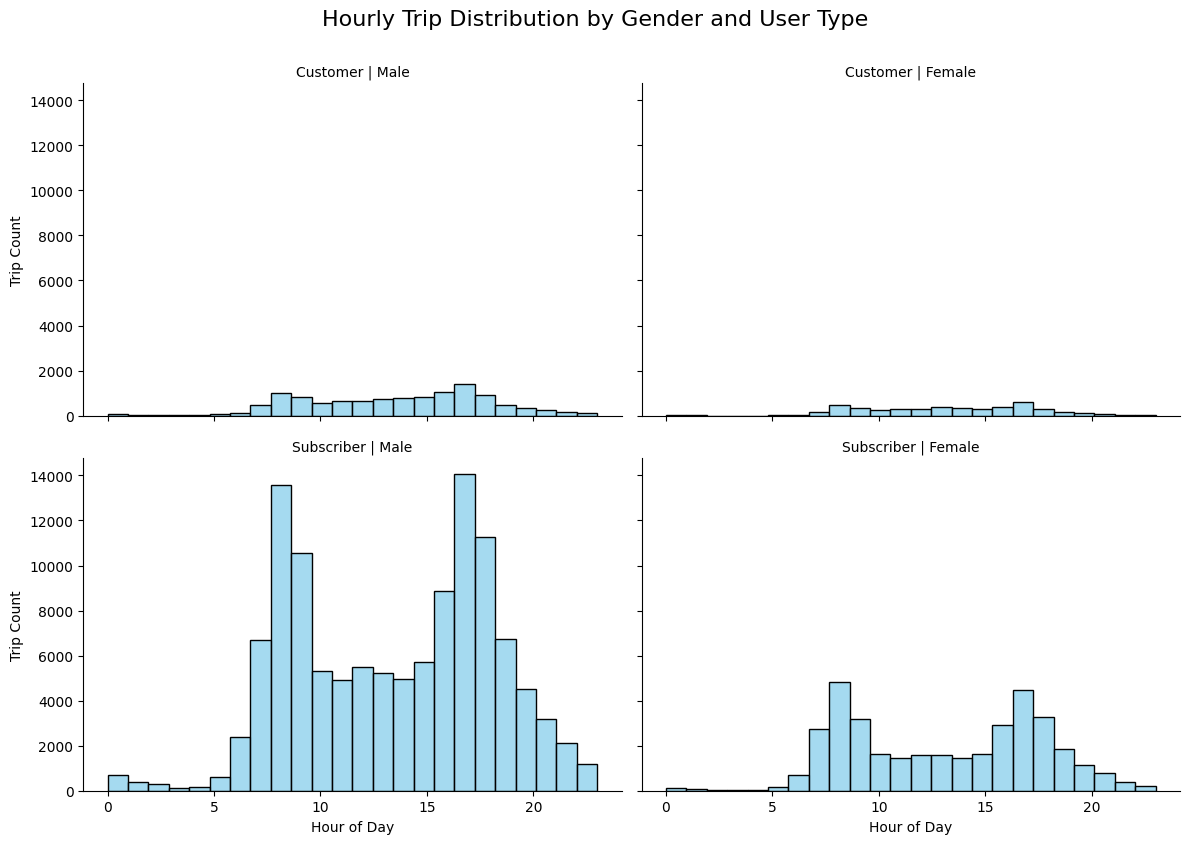

In [19]:
#  When do people ride the most? Facet by user type and gender?
df['hour'] = df['start_time'].dt.hour


g = sns.FacetGrid(df[df['member_gender'].isin(['Male', 'Female'])], 
                  row='user_type', col='member_gender', height=4, aspect=1.5)
g.map(sns.histplot, 'hour', bins=24, color='skyblue', kde=False)
g.set_axis_labels('Hour of Day', 'Trip Count')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.suptitle('Hourly Trip Distribution by Gender and User Type', fontsize=16, y=1.05)
plt.show()



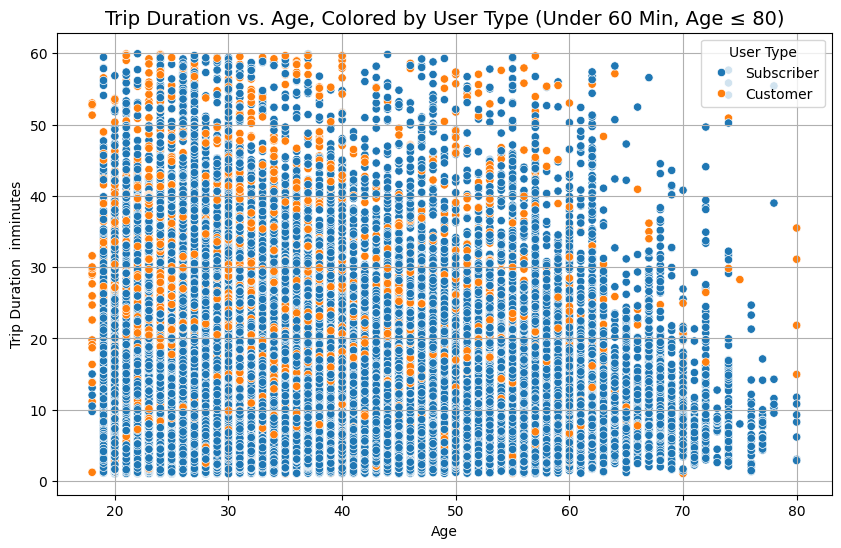

In [22]:
#how does age relate to trip duration and user type? 

scatter_df = df[(df['age'] <= 80) & (df['duration_min'] <= 60)]

plt.figure(figsize=(10,6))
sns.scatterplot(data=scatter_df, x='age', y='duration_min', hue='user_type')
plt.title('Trip Duration vs. Age, Colored by User Type (Under 60 Min, Age ≤ 80)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Trip Duration  inminutes')
plt.grid(True)
plt.legend(title='User Type')
plt.show()


### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> I focused on trip duration as my main feature. I found that the comb. of user type and gender provided a clear understanding of ride behavior.  the customers consistently had longer average trip durations compared to subscribers, and it is true for both genders.

### Were there any interesting or surprising interactions between features?

> an interesting pattern was when analyzing trip duration across weekdays and genders, faceted by user type. Female Casual Users tended to ride longer on weekends compared to weekdays, suggesting more usage patterns, while male Subscribers had more of a consistent and shorter trips throughout the week.

## Conclusions
>You can write a summary of the main findings and reflect on the steps taken during the data exploration.


Summary of Main Findings:
Trip Duration Differences:

Casual Users (Customers) consistently had longer trip durations than Subscribers, indicating more leisure-based use.

Subscribers typically took shorter, more consistent trips, likely for commuting purposes.


Gender and Usage Patterns:

Male users formed the majority across both user types.

Female casual users tended to ride longer on weekends, pointing toward more recreational usage.

Weekday vs. Weekend Behavior:

Weekdays had higher volume for Subscribers (commuters).

Weekends showed longer rides, especially for Casual Users.


> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML.


> At the end of your report, make sure that you export the notebook as an html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep track of where the exported file goes, so you can put it in the same folder as this notebook for project submission. Also, make sure you remove all of the quote-formatted guide notes like this one before you finish your report!

